In [ ]:
import pandas as pd

# Load your file (change filename as needed)
file_path = "train.csv"
df = pd.read_csv(file_path)

# Drop the column (replace 'column_name' with your actual column)
# df = df.drop(columns=["City"])

# Save back to the same file (overwrite)
# df.to_csv(file_path, index=False)


In [17]:
output_file = "train_with_distance.xlsx"
df.to_excel(output_file, index=False)

In [16]:
import pandas as pd
import math

# Helper function: Calculate Haversine Distance between two points in km
def haversine(lat1, lon1, lat2, lon2):
    # Earth radius in kilometers
    R = 6371.0 
    
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    
    return R * c

# 1. Load the dataset
print("Loading train.csv...")
df = pd.read_csv('train.csv')

# 2. Clean string columns (removes trailing/leading spaces from the IDs)
if 'ID' in df.columns:
    df['ID'] = df['ID'].astype(str).str.strip()
if 'Delivery_person_ID' in df.columns:
    df['Delivery_person_ID'] = df['Delivery_person_ID'].astype(str).str.strip()

# 3. Calculate distance and add it as a new column
print("Calculating distances...")
df['Distance_km'] = df.apply(
    lambda row: haversine(
        row['Restaurant_latitude'], 
        row['Restaurant_longitude'], 
        row['Delivery_location_latitude'], 
        row['Delivery_location_longitude']
    ), 
    axis=1
)

# 4. Save the updated dataset to a new CSV file
output_filename = 'train_with_distance.csv'
df.to_csv(output_filename, index=False)

print(f"Success! Updated dataset saved to '{output_filename}'")

# Display the first few rows to verify
print("\nPreview of the new data:")
print(df.head())

Loading train.csv...
Calculating distances...
Success! Updated dataset saved to 'train_with_distance.csv'

Preview of the new data:
       ID Delivery_person_ID  Restaurant_latitude  Restaurant_longitude  \
0  0x4607     INDORES13DEL02            22.745049             75.892471   
1  0xb379     BANGRES18DEL02            12.913041             77.683237   
2  0x5d6d     BANGRES19DEL01            12.914264             77.678400   
3  0x7a6a    COIMBRES13DEL02            11.003669             76.976494   
4  0x70a2     CHENRES12DEL01            12.972793             80.249982   

   Delivery_location_latitude  Delivery_location_longitude  Order_Date  \
0                   22.765049                    75.912471  19-03-2022   
1                   13.043041                    77.813237  25-03-2022   
2                   12.924264                    77.688400  19-03-2022   
3                   11.053669                    77.026494  05-04-2022   
4                   13.012793                  

In [18]:
import pandas as pd
import numpy as np
import math

# 1. Haversine Distance Helper
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

# 2. Generate Random Driver Location Helper
def generate_driver_start(lat, lon, min_r=2.0, max_r=10.0):
    R = 6371.0
    # Random distance and angle
    r = np.random.uniform(min_r, max_r)
    theta = np.random.uniform(0, 2 * math.pi)
    
    lat_rad = math.radians(lat)
    lon_rad = math.radians(lon)
    
    # Calculate new coordinates based on radius and angle
    new_lat_rad = math.asin(math.sin(lat_rad) * math.cos(r/R) + 
                            math.cos(lat_rad) * math.sin(r/R) * math.cos(theta))
    new_lon_rad = lon_rad + math.atan2(math.sin(theta) * math.sin(r/R) * math.cos(lat_rad), 
                                       math.cos(r/R) - math.sin(lat_rad) * math.sin(new_lat_rad))
    return math.degrees(new_lat_rad), math.degrees(new_lon_rad)

# 3. Load the dataset
print("Loading train.csv...")
df = pd.read_csv('train.csv')

# Clean IDs
if 'ID' in df.columns:
    df['ID'] = df['ID'].astype(str).str.strip()
if 'Delivery_person_ID' in df.columns:
    df['Delivery_person_ID'] = df['Delivery_person_ID'].astype(str).str.strip()

# 4. Generate Driver Coordinates
print("Simulating Driver Starting Locations...")
# Apply the generation function and split the tuple into two new columns
df[['Driver_latitude', 'Driver_longitude']] = df.apply(
    lambda row: pd.Series(generate_driver_start(row['Restaurant_latitude'], row['Restaurant_longitude'])), 
    axis=1
)

# 5. Calculate Distances
print("Calculating Distances...")
# Distance 1: Driver to Restaurant (Your 'd' constraint)
df['Driver_to_Rest_Distance_km'] = df.apply(
    lambda row: haversine(
        row['Driver_latitude'], row['Driver_longitude'], 
        row['Restaurant_latitude'], row['Restaurant_longitude']
    ), axis=1
)

# Distance 2: Restaurant to Customer (For your 'tau' constraint later)
df['Rest_to_Cust_Distance_km'] = df.apply(
    lambda row: haversine(
        row['Restaurant_latitude'], row['Restaurant_longitude'], 
        row['Delivery_location_latitude'], row['Delivery_location_longitude']
    ), axis=1
)

# 6. Save to CSV
output_filename = 'train_with_all_distances.csv'
df.to_csv(output_filename, index=False)

print(f"Success! Updated dataset saved to '{output_filename}'")
print("\nNew columns added: 'Driver_latitude', 'Driver_longitude', 'Driver_to_Rest_Distance_km', 'Rest_to_Cust_Distance_km'")

Loading train.csv...
Simulating Driver Starting Locations...
Calculating Distances...
Success! Updated dataset saved to 'train_with_all_distances.csv'

New columns added: 'Driver_latitude', 'Driver_longitude', 'Driver_to_Rest_Distance_km', 'Rest_to_Cust_Distance_km'


Loading dataset...
Building Graph Nodes and Base Edges...
Mapping Drivers to Restaurants using optimized BallTree (Fast)...
Graph Construction Complete: 47617 Nodes, 66143 Edges.
Generating visualization...


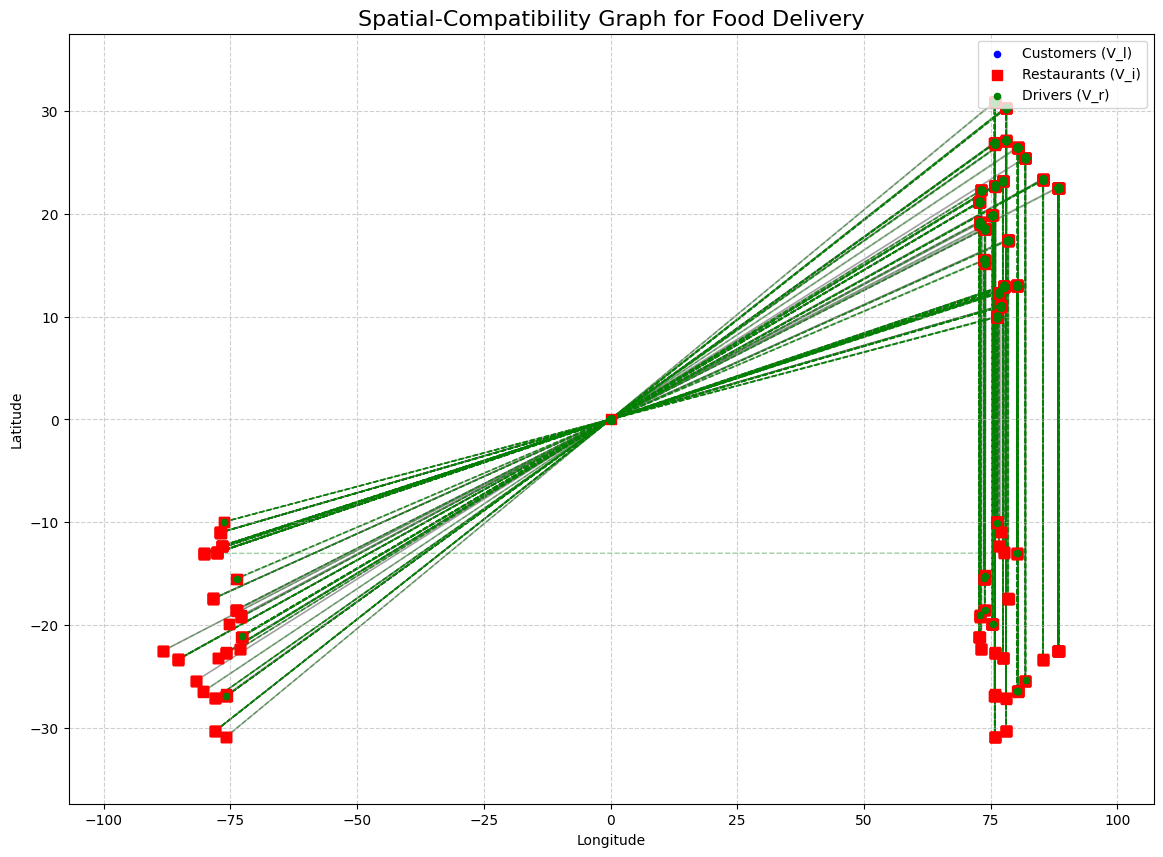

In [32]:
import pandas as pd
import networkx as nx
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# --- Set Feasibility Constraints ---
DISTANCE_THRESHOLD_KM = 5.0  
MAX_TIME_MINUTES = 45.0      
AVERAGE_SPEED_KMH = 30.0     
PICKUP_BUFFER_MIN = 5.0      

print("Loading dataset...")
df = pd.read_csv('train_with_all_distances.csv')
# df = df.head(20000)
G = nx.Graph()
print("Building Graph Nodes and Base Edges...")

# 1. Build Nodes and Base Edges (Ensuring lat/lon are attached)
for index, row in df.iterrows():
    cust_node = f"Cust_{row['ID']}"
    rest_node = f"Rest_{round(row['Restaurant_latitude'], 4)}_{round(row['Restaurant_longitude'], 4)}"
    driver_node = f"Driver_{row['Delivery_person_ID']}"
    
    # Add nodes WITH coordinates
    G.add_node(cust_node, partition='V_l', type='online_customer', 
               lat=row['Delivery_location_latitude'], lon=row['Delivery_location_longitude'])
    G.add_node(rest_node, partition='V_i', type='offline_restaurant', 
               lat=row['Restaurant_latitude'], lon=row['Restaurant_longitude'])
    G.add_node(driver_node, partition='V_r', type='online_driver', 
               lat=row['Driver_latitude'], lon=row['Driver_longitude'])
    
    # Edge Rule 1: Customer -> Restaurant
    dist_rest_to_cust = row['Rest_to_Cust_Distance_km']
    G.add_edge(cust_node, rest_node, weight=dist_rest_to_cust, edge_type='order')

print("Mapping Drivers to Restaurants using optimized BallTree (Fast)...")

# 2. Optimized Mapping using BallTree
unique_drivers = df[['Delivery_person_ID', 'Driver_latitude', 'Driver_longitude']].drop_duplicates().reset_index(drop=True)
unique_restaurants = df[['Restaurant_latitude', 'Restaurant_longitude']].drop_duplicates().reset_index(drop=True)

driver_coords_rad = np.radians(unique_drivers[['Driver_latitude', 'Driver_longitude']].values)
rest_coords_rad = np.radians(unique_restaurants[['Restaurant_latitude', 'Restaurant_longitude']].values)

tree = BallTree(rest_coords_rad, metric='haversine')
radius_rad = DISTANCE_THRESHOLD_KM / 6371.0
indices_within_radius = tree.query_radius(driver_coords_rad, r=radius_rad)

# Helper function for exact edge weight calculation
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    return R * 2 * math.atan2(math.sqrt(math.sin((lat2 - lat1)/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1)/2)**2), math.sqrt(1-(math.sin((lat2 - lat1)/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1)/2)**2)))

for driver_idx, matching_rest_indices in enumerate(indices_within_radius):
    if len(matching_rest_indices) == 0:
        continue
        
    driver_row = unique_drivers.iloc[driver_idx]
    driver_node = f"Driver_{driver_row['Delivery_person_ID']}"
    
    for rest_idx in matching_rest_indices:
        rest_row = unique_restaurants.iloc[rest_idx]
        rest_node = f"Rest_{round(rest_row['Restaurant_latitude'], 4)}_{round(rest_row['Restaurant_longitude'], 4)}"
        
        # Check if node exists to prevent blank nodes from breaking the plot
        if G.has_node(rest_node) and G.has_node(driver_node):
            dist = haversine(driver_row['Driver_latitude'], driver_row['Driver_longitude'],
                             rest_row['Restaurant_latitude'], rest_row['Restaurant_longitude'])
            G.add_edge(rest_node, driver_node, weight=dist, edge_type='eligible_pickup')

print(f"Graph Construction Complete: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges.")
print("Generating visualization...")

# 3. Visualization Phase (with bulletproof safeguards)
# Safely extract coordinates, ignoring any accidental empty nodes
pos = {}
for node, data in G.nodes(data=True):
    if 'lon' in data and 'lat' in data:
        if not pd.isna(data['lon']) and not pd.isna(data['lat']):
            pos[node] = (data['lon'], data['lat'])

# Filter out nodes that don't have valid positions so drawing doesn't crash
customers = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_l' and n in pos]
restaurants = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_i' and n in pos]
drivers = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_r' and n in pos]

order_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'order' and u in pos and v in pos]
pickup_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'eligible_pickup' and u in pos and v in pos]

plt.figure(figsize=(14, 10))
plt.title("Spatial-Compatibility Graph for Food Delivery", fontsize=16)

# Draw Nodes
nx.draw_networkx_nodes(G, pos, nodelist=customers, node_color='blue', node_size=20, label='Customers (V_l)')
nx.draw_networkx_nodes(G, pos, nodelist=restaurants, node_color='red', node_shape='s', node_size=50, label='Restaurants (V_i)')
nx.draw_networkx_nodes(G, pos, nodelist=drivers, node_color='green', node_size=20, label='Drivers (V_r)')

# Draw Edges
nx.draw_networkx_edges(G, pos, edgelist=order_edges, edge_color='gray', style='solid', alpha=0.3)
nx.draw_networkx_edges(G, pos, edgelist=pickup_edges, edge_color='green', style='dashed', alpha=0.2)

plt.legend(scatterpoints=1, loc='upper right')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True) 

plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# print("Generating visualization...")

# # 1. Extract physical coordinates for the layout
# # We map (x, y) to (longitude, latitude)
# pos = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}

# # 2. Separate nodes by their tripartite partition so we can color-code them
# customers = [n for n, d in G.nodes(data=True) if d['partition'] == 'V_l']
# restaurants = [n for n, d in G.nodes(data=True) if d['partition'] == 'V_i']
# drivers = [n for n, d in G.nodes(data=True) if d['partition'] == 'V_r']

# # 3. Separate edges by type so we can style them differently
# order_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'order']
# pickup_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'eligible_pickup']

# # 4. Set up the plot canvas
# plt.figure(figsize=(12, 10))
# plt.title("Spatial-Compatibility Graph for Food Delivery", fontsize=16)

# # --- Draw Nodes ---
# # Customers: Blue dots
# nx.draw_networkx_nodes(G, pos, nodelist=customers, node_color='blue', node_size=50, label='Customers (V_l)')
# # Restaurants: Red squares
# nx.draw_networkx_nodes(G, pos, nodelist=restaurants, node_color='red', node_shape='s', node_size=100, label='Restaurants (V_i)')
# # Drivers: Green dots
# nx.draw_networkx_nodes(G, pos, nodelist=drivers, node_color='green', node_size=50, label='Drivers (V_r)')

# # --- Draw Edges ---
# # Customer to Restaurant (Firm orders): Solid gray lines
# nx.draw_networkx_edges(G, pos, edgelist=order_edges, edge_color='gray', style='solid', alpha=0.5)
# # Driver to Restaurant (Eligible pickups based on distance 'd'): Dashed green lines
# nx.draw_networkx_edges(G, pos, edgelist=pickup_edges, edge_color='green', style='dashed', alpha=0.4)

# # 5. Add labels and display
# plt.legend(scatterpoints=1, loc='upper right')
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.grid(True, linestyle='--', alpha=0.6)

# # Turn on axis numbers to see the coordinate grid
# plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True) 

# plt.show()

Generating visualization...


KeyError: 'lon'